In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Telco.csv")

In [5]:
import matplotlib.pyplot as plt

In [6]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


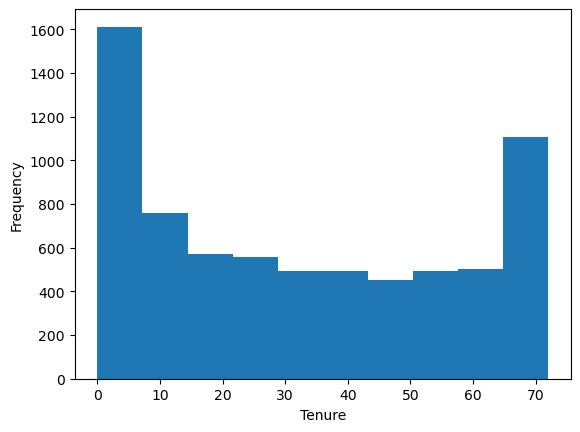

In [13]:
plt.hist(df["tenure"])
plt.xlabel("Tenure")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# it is somehow in u shaped distribution with many customers having either very long or very short tenures

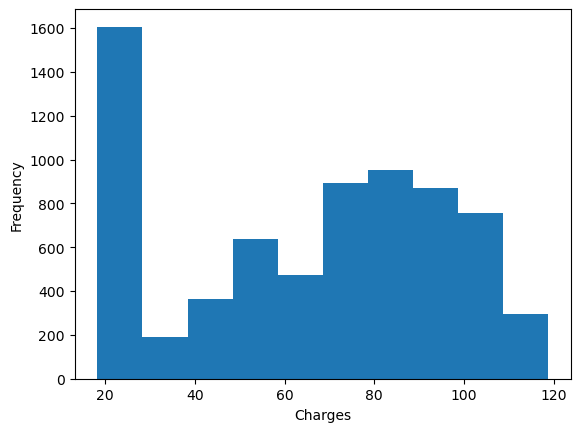

In [14]:
plt.hist(df["MonthlyCharges"])
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#Does not look like normally distributed.It has large concentration of customers around lower charges and another broad concentration.


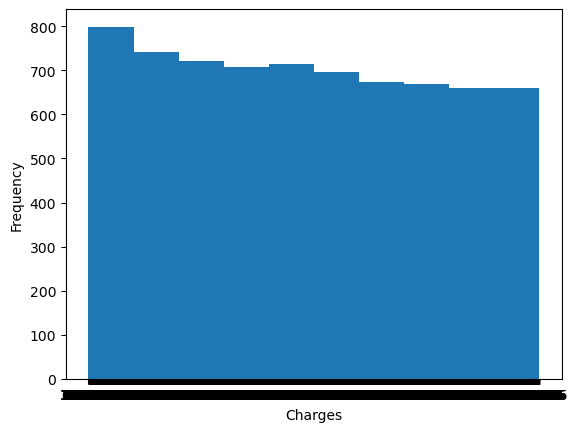

In [15]:
plt.hist(df["TotalCharges"])
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#it looks right skewed , The frequency gradually decreases as TotalCharges increases.

In [16]:
df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors="coerce")

In [17]:
monthly_charges = df["MonthlyCharges"].dropna()

In [18]:
#taking one random sample of 30 customers

In [19]:
sample = monthly_charges.sample(n=30)

sample_mean = sample.mean()

print(sample_mean)

64.14166666666667


In [20]:
#im going to repeat it 1k times

In [21]:
sample_means = []

for i in range(1000):
    sample = monthly_charges.sample(n=30)
    sample_mean = sample.mean()
    sample_means.append(sample_mean)

In [22]:
len(sample_means)

1000

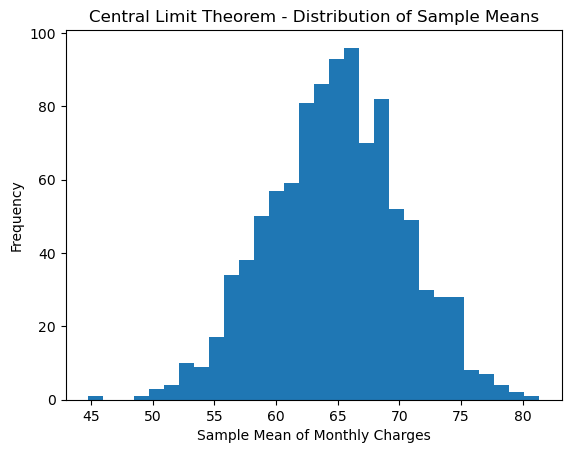

In [23]:
plt.hist(sample_means, bins=30)

plt.xlabel("Sample Mean of Monthly Charges")
plt.ylabel("Frequency")
plt.title("Central Limit Theorem - Distribution of Sample Means")

plt.show()


(array([1184.,  193.,  229.,   83.,   42.,   66.,   88.,  145.,  132.,
         288.,  186.,  165.,  218.,  129.,  126.,  376.,  295.,  224.,
         430.,  283.,  240.,  367.,  295.,  207.,  325.,  250.,  183.,
         166.,   76.,   52.]),
 array([ 18.25,  21.6 ,  24.95,  28.3 ,  31.65,  35.  ,  38.35,  41.7 ,
         45.05,  48.4 ,  51.75,  55.1 ,  58.45,  61.8 ,  65.15,  68.5 ,
         71.85,  75.2 ,  78.55,  81.9 ,  85.25,  88.6 ,  91.95,  95.3 ,
         98.65, 102.  , 105.35, 108.7 , 112.05, 115.4 , 118.75]),
 <BarContainer object of 30 artists>)

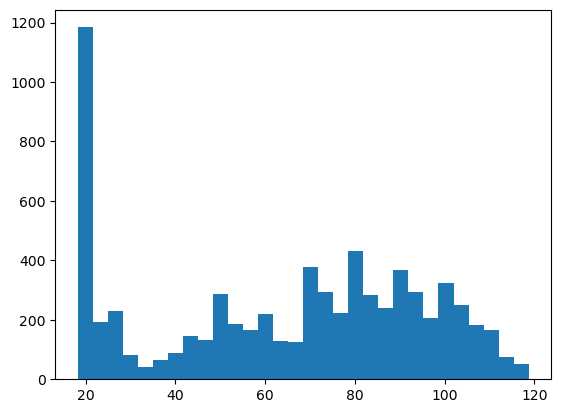

In [24]:
plt.hist(df["MonthlyCharges"], bins=30)

In [27]:
# after repeatedly taking random samples of 30 customers and calculating their mean the distribution of the sample mean looks normal


In [28]:
# "if 27% of customers churn, what's the probability that 8 out of 30 random customers churned"

In [29]:
from scipy.stats import binom

probability = binom.pmf(8, 30, 0.27)

print(probability)

0.16269941634137092


In [30]:
## test 1 does churn differ by contract type?

In [34]:
from scipy.stats import chi2_contingency
contract_churn = pd.crosstab(df["Contract"], df["Churn"])

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [35]:
chi2, p, dof, expected = chi2_contingency(contract_churn)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 1184.5965720837926
p-value: 5.863038300673391e-258
Degrees of freedom: 2


In [36]:
alpha = 0.05

if p < alpha:
    print("Reject the null hypothesis.")
    print("Contract type and churn are significantly associated.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is not enough evidence of an association between contract type and churn.")

Reject the null hypothesis.
Contract type and churn are significantly associated.


In [37]:
churned = df[df["Churn"] == "Yes"]["MonthlyCharges"]
non_churned = df[df["Churn"] == "No"]["MonthlyCharges"]

print("Churned customers:", len(churned))
print("Non-churned customers:", len(non_churned))

Churned customers: 1869
Non-churned customers: 5174


In [38]:
from scipy.stats import shapiro

stat_yes, p_yes = shapiro(churned)
stat_no, p_no = shapiro(non_churned)

print("Churned - Shapiro p-value:", p_yes)
print("Non-churned - Shapiro p-value:", p_no)

Churned - Shapiro p-value: 5.363083193564134e-29
Non-churned - Shapiro p-value: 1.647618321182357e-47


C:\Users\Shoaib Akbar\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5174.
  res = hypotest_fun_out(*samples, **kwds)


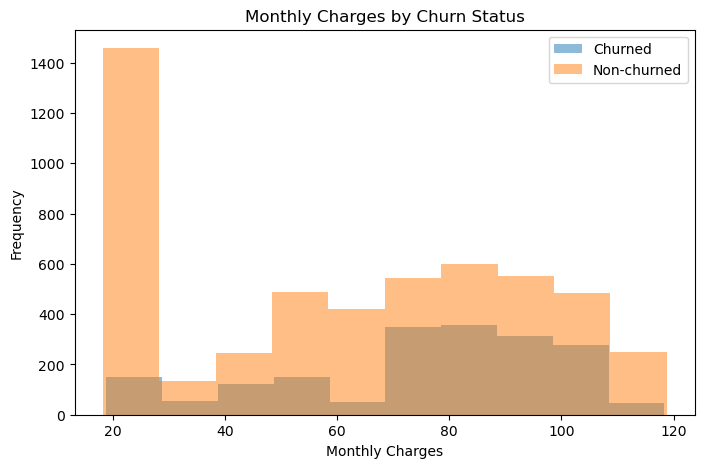

In [40]:

plt.figure(figsize=(8, 5))

plt.hist(churned, alpha=0.5, label="Churned")
plt.hist(non_churned, alpha=0.5, label="Non-churned")

plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.title("Monthly Charges by Churn Status")
plt.legend()
plt.show()

In [41]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    churned,
    non_churned,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 18.407526676414673
p-value: 8.59244933154705e-73


In [42]:
if p_value < 0.05:
    print("Reject the null hypothesis.")
    print("Monthly charges are significantly different between churned and non-churned customers.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is not enough evidence that monthly charges differ between the two groups.")

Reject the null hypothesis.
Monthly charges are significantly different between churned and non-churned customers.


In [43]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"]
)

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


In [44]:
chi2_payment, p_payment, dof_payment, expected_payment = chi2_contingency(
    payment_churn
)

print("Chi-square statistic:", chi2_payment)
print("p-value:", p_payment)
print("Degrees of freedom:", dof_payment)

Chi-square statistic: 648.1423274814
p-value: 3.6823546520097993e-140
Degrees of freedom: 3


In [45]:
if p_payment < 0.05:
    print("Reject the null hypothesis.")
    print("Payment method and churn are significantly associated.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is not enough evidence of an association between payment method and churn.")

Reject the null hypothesis.
Payment method and churn are significantly associated.


In [46]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"])

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [47]:
chi2, p, dof, expected = chi2_contingency(contract_churn)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)


Chi-square statistic: 1184.5965720837926
p-value: 5.863038300673391e-258
Degrees of freedom: 2


In [48]:
#here is a statistically significant association between contract type and churn. However, this does not prove that contract type causes churn.



In [49]:
# now we test churn vs monthly charges


In [50]:
churned = df[df["Churn"] == "Yes"]["MonthlyCharges"]
non_churned = df[df["Churn"] == "No"]["MonthlyCharges"]

In [51]:
from scipy.stats import shapiro

stat_yes, p_yes = shapiro(churned)
stat_no, p_no = shapiro(non_churned)

print("Churned p-value:", p_yes)
print("Non-churned p-value:", p_no)

Churned p-value: 5.363083193564134e-29
Non-churned p-value: 1.647618321182357e-47


C:\Users\Shoaib Akbar\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5174.
  res = hypotest_fun_out(*samples, **kwds)


In [52]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    churned,
    non_churned,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 18.407526676414673
p-value: 8.59244933154705e-73


In [56]:
# Task 3 correlation vs Causation